In [2]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Define the folder path
folder_path = ('E:\Desktop\\all_data\data8')

# Initialize empty lists to store the results
results = []

# Iterate over files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        # Read the data
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path)
        # Extract the required data columns
        L= df['LBD'].dropna()
        #L = df['LBD'].dropna()
        P1 = df['RPU'].dropna()
        I = df['inducer'].dropna()
        Imax = 35.84931505
        #I0 = df['I0'].dropna()
        #I0 = I0.values.flatten()[0]
        I0=0.035485714

        # Define the objective function
        def func(I, k1,k2, k3,kd):
            if  not 0 < k1 or not 0 < k2 or not 0 < k3 or not 0 < kd :
                return np.ones_like(L) * 1e10  # 返回一个大的
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0

        # Use curve_fit function to fit model parameters
        #param_bounds=([0,0,0,0],[1000,10000,10000,10000])
        params, pcov = curve_fit(func, I, P1, p0=[0.00001,1.00,0.010,10.00],maxfev = 1000000)#,bounds=param_bounds)

        k1, k2, k3 ,kd = params

        # Compute the fitted curve
        P1_fit = func(I, k1, k2, k3 ,kd)

        # Calculate the sum of squared residuals
        residuals = P1 - P1_fit
        ssr = np.sum(residuals ** 2)

        # Append the results to the list
        result = {'File': file_name,'k1': k1,'k2': k2, 'k3': k3,'kd': kd, 'error': ssr}
        results.append(result)

# Create a DataFrame from the results list
results_df = pd.DataFrame(results)

# Transpose the DataFrame
results_df_transposed = results_df.transpose()

# Save the transposed results to a CSV file
results_df_transposed.to_csv('E:\Desktop\\fit_k1k2k3kd.csv', header=False, index=False)

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Define the folder path
folder_path = ('E:\Desktop\\all_data\data8')

# Initialize empty lists to store the results
results = []

# Iterate over files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        # Read the data
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path)
        # Extract the required data columns
        L= df['LBD'].dropna()
        #L = df['LBD'].dropna()
        P1 = df['RPU'].dropna()
        I = df['inducer'].dropna()
        Imax = 35.84931505
        #I0 = df['I0'].dropna()
        #I0 = I0.values.flatten()[0]
        I0=0.035485714
        k1=0.000171923

        k2=0.256016091
        k3=225.0817618

        # Define the objective function
        def func(I, kd):
            if  not 0 < k1 or not 0 < k2 or not 0 < k3 or not 0 < kd :
                return np.ones_like(L) * 1e10  # 返回一个大的
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0

        # Use curve_fit function to fit model parameters
        #param_bounds=([0,0,0,0],[1000,10000,10000,10000])
        params, pcov = curve_fit(func, I, P1, p0=[10.00],maxfev = 1000000)#,bounds=param_bounds)

        kd = params

        # Compute the fitted curve
        P1_fit = func(I, kd)

        # Calculate the sum of squared residuals
        residuals = P1 - P1_fit
        ssr = np.sum(residuals ** 2)

        # Append the results to the list
        result = {'File': file_name,'k1': k1,'k2': k2, 'k3': k3,'kd': kd, 'error': ssr}
        results.append(result)

# Create a DataFrame from the results list
results_df = pd.DataFrame(results)

# Transpose the DataFrame
results_df_transposed = results_df.transpose()

# Save the transposed results to a CSV file
results_df_transposed.to_csv('E:\Desktop\\fit_k1k2k3kd.csv', header=False, index=False)

kb/kb_fitter

k1/k2/k3_fitter

In [8]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Define the folder path
folder_path = ('E:\Desktop\quantification&crossvalidation4\LBD')

# Initialize empty lists to store the results
results = []

# Iterate over files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        # Read the data
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path)
        # Extract the required data columns
        L= df['LBD'].dropna()
        #L = df['LBD'].dropna()
        P1 = (df['RPU']).dropna()
        I = df['inducer'].dropna()
        Imax = 35.84931505
        #I0 = df['I0'].dropna()
        #I0 = I0.values.flatten()[0]
        kd=df['kd'].dropna()
        I0=0.035485714

        # Define the objective function
        def func(x, k1, k2, k3):
            L, I = x
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * (((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd) / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)

        # Use curve_fit function to fit model parameters
        param_bounds=([0,0,0],[1000,1000,10000])
        params, pcov = curve_fit(func, (L,I), P1, p0=[0.0001, 1.00000,0.01],maxfev = 1000000000,bounds=param_bounds)

        k1, k2, k3 = params

        # Compute the fitted curve
        P1_fit = func( (L,I),k1, k2, k3)

        # Calculate the sum of squared residuals
        residuals = P1 - P1_fit
        ssr = np.sum(residuals ** 2)

        # Append the results to the list
        result = {'File': file_name, 'k1': k1, 'k2': k2, 'k3': k3, 'error': ssr}
        results.append(result)

# Create a DataFrame from the results list
results_df = pd.DataFrame(results)

# Transpose the DataFrame
results_df_transposed = results_df.transpose()

# Save the transposed results to a CSV file
results_df_transposed.to_csv('E:\Desktop\\fit_all_results.csv', header=False, index=False)

核受体

二聚化

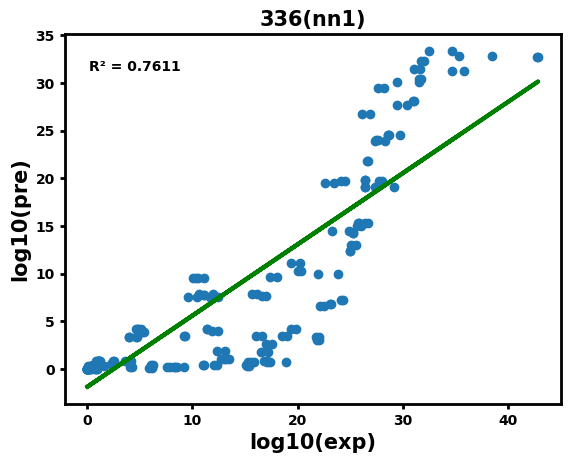

Correlation: 0.8724


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Read the data
df = pd.read_csv('E:\Desktop\LuxR_C6.csv')

# Extract the required data columns

L =df['LBD'].dropna()


P1 =df['RPU'].dropna()
I = df['inducer'].dropna()
k1=0.00038519687950611115
k2=0.020147820934653282
k3=0.051162322014570236

Imax=35.84931505

kd=14.541175842285156

'''
x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
F1 = np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd)
F2 = np.log(L / 2) + np.log((x2 - (k2*I+1)) / (x2 + (k2*I+1))) + np.log(kd)
deltaF=F1-F2
P1=(Imax / (1 + np.exp(-F1))) 
P2=(Imax / (1 + np.exp(-F2)))
deltaP=P1-P2
print(deltaF)
print(deltaP)

'''

# Define the objective function
def func(L, k1, k2, k3,kd):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0

# Compute the fitted curve
P1_fit = func(L, k1, k2,k3,kd)
fig, ax = plt.subplots()
# Calculate the correlation
slope, intercept, r_value, p_value, std_err = linregress(P1, P1_fit)
r_squared = r_value**2

# Plot the data points and correlation line
plt.scatter(P1, P1_fit)
plt.xlabel('log10(exp)',fontsize=15,weight='bold') 
plt.ylabel('log10(pre)',fontsize=15,weight='bold')
plt.title('336(nn1)',fontsize=15,weight='bold')
plt.plot(P1, slope * P1 + intercept,c='g',linewidth=3)
plt.annotate('R² = {:.4f}'.format(r_squared), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#plt.savefig('E:\Desktop\\375.svg')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.show()


print('Correlation: %.4f' % r_value)

In [7]:
import os
import numpy as np
import pandas as pd
from scipy.stats import linregress

# 指定文件夹路径
folder_path = 'E:/Desktop/data/data4/'

# 读取文件夹中的所有文件
file_names = os.listdir(folder_path)

# 创建一个空列表来存储每个文件的 R 方值
r_squared_values = []
k1=0.000153468

k2=0.002735345


k3=0.050865889

Imax=35.84931505


# 循环迭代文件夹中的每个文件
for file_name in file_names:
    # 拼接文件的完整路径
    file_path = os.path.join(folder_path, file_name)
    
    # 读取文件数据
    df = pd.read_csv(file_path)
    
    # 提取所需的数据列
    L = df['LBD'].dropna()
    P1 = df['RPU'].dropna()
    I = df['inducer'].dropna()
    I0 = df['I0'].dropna()
    kd= df['kd'].dropna()
    
    # 定义目标函数
    def func(L, k1, k2, k3, kd, I0, Imax):
        x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
        return Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0
    
    # 计算拟合曲线
    P1_fit = func(L, k1, k2, k3, kd, I0, Imax)
    
    # 计算相关系数
    slope, intercept, r_value, p_value, std_err = linregress(P1, P1_fit)
    r_squared = r_value**2
    
    # 将计算得到的 R 方值添加到列表中
    r_squared_values.append(r_squared)

    # 输出文件名和对应的 R 方值
    print(f'{file_name}: R squared = {r_squared}')

# 创建包含文件名和对应 R 方值的 DataFrame
result_df = pd.DataFrame({'File Name': file_names, 'R Squared': r_squared_values})

# 保存 DataFrame 到 CSV 文件
output_file_path = 'E:/Desktop/BjaR.csv'
result_df.to_csv(output_file_path, index=False)

print(f'Average R squared across all files: {np.mean(r_squared_values)}')
print(f'Results saved to: {output_file_path}')

329.csv: R squared = 0.9540590424081468
379.csv: R squared = 0.9634881880285467
380.csv: R squared = 0.976040219009346
Average R squared across all files: 0.9645291498153465
Results saved to: E:/Desktop/BjaR.csv


In [47]:
import os
import numpy as np
import pandas as pd
from scipy.stats import linregress

# 指定文件夹路径
folder_path = 'E:/Desktop/data/data9/'

# 创建一个空列表来存储每个文件的 R 方值
all_results = []

k1 = 0.000109651

k2 = 0.181526351

k3 = 0.060416246
Imax = 35.84931505

# 定义 LBD 档次的阈值
low_threshold = 1
medium_threshold = 5
high_threshold = 10

# 循环迭代文件夹中的每个文件
for file_name in os.listdir(folder_path):
    # 拼接文件的完整路径
    file_path = os.path.join(folder_path, file_name)
    
    # 读取文件数据
    df = pd.read_csv(file_path)
    
    # 提取所需的数据列
    L_values = df['LBD'].dropna()  # 获取 LBD 值
    
    # 创建空列表以存储每个 LBD 档次对应的 R 方值和其对应的文件名
    low_r_squared = []
    medium_r_squared = []
    high_r_squared = []
    
    # 根据 LBD 档次计算 R 方值
    for L in L_values:
        P1 = df[df['LBD'] == L]['RPU'].dropna()
        I = df[df['LBD'] == L]['inducer'].dropna()
        I0 = df[df['LBD'] == L]['I0'].dropna()
        kd = df[df['LBD'] == L]['kd'].dropna()
        
        # 检查 P1 是否具有足够的差异来进行线性回归
        if np.std(P1) == 0:
            print(f"Cannot calculate linear regression for {file_name}. All x values are identical.")
            continue
        
        # 定义目标函数
        def func(L, k1, k2, k3, kd, I0, Imax):
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0
        
        # 计算拟合曲线
        P1_fit = func(L, k1, k2, k3, kd, I0, Imax)
        
        # 计算相关系数
        slope, intercept, r_value, p_value, std_err = linregress(P1, P1_fit)
        r_squared = r_value**2
        
        # 决定 LBD 属于哪个档次，并将对应的 R 方值添加到相应的列表中
        if L <= low_threshold:
            low_r_squared.append(r_squared)
        elif low_threshold < L <= medium_threshold:
            medium_r_squared.append(r_squared)
        else:
            high_r_squared.append(r_squared)
    
    # 计算每个文件对应低、中、高三个档次的 R 方值的平均值，并将结果添加到总列表中
    low_r_squared_mean = np.mean(low_r_squared)
    medium_r_squared_mean = np.mean(medium_r_squared)
    high_r_squared_mean = np.mean(high_r_squared)
    all_results.append([file_name, low_r_squared_mean, medium_r_squared_mean, high_r_squared_mean])

# 创建包含文件名和对应低、中、高三个档次的 R 方值的 DataFrame
result_df = pd.DataFrame(all_results, columns=['File Name', 'Low R Squared', 'Medium R Squared', 'High R Squared'])

# 将 DataFrame 写入 CSV 文件
output_file_path = 'E:/Desktop/CV/TraR_LBD_Categorized.csv'
result_df.to_csv(output_file_path, index=False)

print(f'Results saved to: {output_file_path}')

Results saved to: E:/Desktop/CV/TraR_LBD_Categorized.csv


核受体

In [51]:
import os
import numpy as np
import pandas as pd
from scipy.stats import linregress

# 指定文件夹路径
folder_path = 'E:/Desktop/data/data11/'

# 创建一个空列表来存储每个文件的 R 方值
all_results = []

k1 = 4.93E-06

k2 = 2.473198866

k3 = 0.001227192

kx1=2.886204118

kx2=1.77914886

Imax = 35.84931505

# 定义 LBD 档次的阈值
low_threshold = 1
medium_threshold = 5
high_threshold = 10

# 循环迭代文件夹中的每个文件
for file_name in os.listdir(folder_path):
    # 拼接文件的完整路径
    file_path = os.path.join(folder_path, file_name)
    
    # 读取文件数据
    df = pd.read_csv(file_path)
    
    # 提取所需的数据列
    L_values = df['LBD'].dropna()  # 获取 LBD 值
    
    # 创建空列表以存储每个 LBD 档次对应的 R 方值和其对应的文件名
    low_r_squared = []
    medium_r_squared = []
    high_r_squared = []
    
    # 根据 LBD 档次计算 R 方值
    for L in L_values:
        P1 = df[df['LBD'] == L]['RPU'].dropna()
        I = df[df['LBD'] == L]['inducer'].dropna()
        I0 = df[df['LBD'] == L]['I0'].dropna()
        kd = df[df['LBD'] == L]['kd'].dropna()
        
        # 检查 P1 是否具有足够的差异来进行线性回归
        if np.std(P1) == 0:
            print(f"Cannot calculate linear regression for {file_name}. All x values are identical.")
            continue
        
        # 定义目标函数
        def func(L, k1, k2, k3, kd,kx1,kx2, I0, Imax):
            x1 =np.sqrt((k2*I+kx1+kx2*k2*I+1)*(k2*I+kx1+kx2*k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1+k1*kx1*kx1+k3*k2*k2*kx2*kx2*I*I))
            return (Imax * ((L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) * kd / (1 + (L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) *kd)) + I0)
        
        # 计算拟合曲线
        P1_fit = func(L, k1, k2, k3, kd,kx1,kx2, I0, Imax)
        
        # 计算相关系数
        slope, intercept, r_value, p_value, std_err = linregress(P1, P1_fit)
        r_squared = r_value**2
        
        # 决定 LBD 属于哪个档次，并将对应的 R 方值添加到相应的列表中
        if L <= low_threshold:
            low_r_squared.append(r_squared)
        elif low_threshold < L <= medium_threshold:
            medium_r_squared.append(r_squared)
        else:
            high_r_squared.append(r_squared)
    
    # 计算每个文件对应低、中、高三个档次的 R 方值的平均值，并将结果添加到总列表中
    low_r_squared_mean = np.mean(low_r_squared)
    medium_r_squared_mean = np.mean(medium_r_squared)
    high_r_squared_mean = np.mean(high_r_squared)
    all_results.append([file_name, low_r_squared_mean, medium_r_squared_mean, high_r_squared_mean])

# 创建包含文件名和对应低、中、高三个档次的 R 方值的 DataFrame
result_df = pd.DataFrame(all_results, columns=['File Name', 'Low R Squared', 'Medium R Squared', 'High R Squared'])

# 将 DataFrame 写入 CSV 文件
output_file_path = 'E:/Desktop/CV/MR_LBD_Categorized.csv'
result_df.to_csv(output_file_path, index=False)

print(f'Results saved to: {output_file_path}')

Results saved to: E:/Desktop/CV/MR_LBD_Categorized.csv


0     -1.755102
1     -1.293830
2     -0.134020
3      0.363273
4      0.761326
         ...   
328    0.254707
329    0.802823
330    1.447257
331    1.518053
332    1.540076
Length: 333, dtype: float64


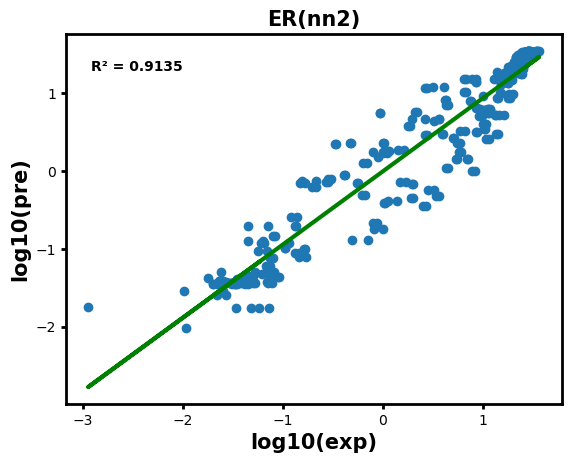

Correlation: 0.9558


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Read the data
df = pd.read_csv('E:\Desktop\quantification&crossvalidation\\330.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = np.log10(df['RPU']).dropna()
I = df['inducer'].dropna()
k1=3.58E-05

k2=4.642582893

k3=0.305897862


kx1=0.998622835

kx2=5.876236916



Imax=35.84931505

I0=df['I0'].dropna()


kd=df['kd'].dropna()



# Define the objective function
def func(L, k1, k2, k3,kx1,kx2):  
        x1 = np.sqrt((k2*I+kx1+kx2*k2*I+1)*(k2*I+kx1+kx2*k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1+k1*kx1*kx1+k3*k2*k2*kx2*kx2*I*I))
        #x2 = torch.sqrt(1 + 8 * L * self.k1)
        P1 = (Imax * ((L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) * kd / (1 + (L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) *kd)) + I0)
        return np.log10(P1)
# Compute the fitted curve
P1_fit = func(L, k1, k2,k3,kx1,kx2)
fig, ax = plt.subplots()
# Calculate the correlation
slope, intercept, r_value, p_value, std_err = linregress(P1, P1_fit)
r_squared = r_value**2

# Plot the data points and correlation line
plt.scatter(P1, P1_fit)
plt.xlabel('log10(exp)',fontsize=15,weight='bold') 
plt.ylabel('log10(pre)',fontsize=15,weight='bold')
plt.title('ER(nn2)',fontsize=15,weight='bold')
plt.plot(P1, slope * P1 + intercept,c='g',linewidth=3)
plt.annotate('R² = {:.4f}'.format(r_squared), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#plt.savefig('E:\Desktop\\375.svg')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
print(P1_fit)
plt.show()


print('Correlation: %.4f' % r_value)

In [9]:
import os
import numpy as np
import pandas as pd
from scipy.stats import linregress

# 指定文件夹路径
folder_path = 'E:/Desktop/mamm/DHBR'

# 读取文件夹中的所有文件
file_names = os.listdir(folder_path)

# 创建一个空列表来存储每个文件的 R 方值
r_squared_values = []
k1=6.05307E-06


k2=2.759776115


k3=0.028730787


kx1=0.997333705



kx2=2.137547731
Imax=13.609108165


# 循环迭代文件夹中的每个文件
for file_name in file_names:
    # 拼接文件的完整路径
    file_path = os.path.join(folder_path, file_name)
    
    # 读取文件数据
    df = pd.read_csv(file_path)
    
    # 提取所需的数据列
    L = df['LBD'].dropna()
    P1 = df['RPU'].dropna()
    I = df['inducer'].dropna()
    I0 = 0.04
    kd= df['kd'].dropna()
    
    # 定义目标函数
    def func(L, k1, k2, k3, kd,kx1,kx2, I0, Imax):
        x1 = np.sqrt((k2*I+kx1+kx2*k2*I+1)*(k2*I+kx1+kx2*k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1+k1*kx1*kx1+k3*k2*k2*kx2*kx2*I*I))
        return (Imax * ((L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) * kd / (1 + (L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) *kd)) + I0)
    
    # 计算拟合曲线
    P1_fit = func(L, k1, k2, k3, kd,kx1,kx2,  I0, Imax)
    
    # 计算相关系数
    slope, intercept, r_value, p_value, std_err = linregress(P1, P1_fit)
    r_squared = r_value**2
    
    # 将计算得到的 R 方值添加到列表中
    r_squared_values.append(r_squared)

    # 输出文件名和对应的 R 方值
    print(f'{file_name}: R squared = {r_squared}')

# 创建包含文件名和对应 R 方值的 DataFrame
result_df = pd.DataFrame({'File Name': file_names, 'R Squared': r_squared_values})

# 保存 DataFrame 到 CSV 文件
output_file_path = 'E:/Desktop/mamm/DHBR.csv'
result_df.to_csv(output_file_path, index=False)

print(f'Average R squared across all files: {np.mean(r_squared_values)}')
print(f'Results saved to: {output_file_path}')

408.csv: R squared = 0.5381040599083085
409.csv: R squared = 0.682062633261557
Average R squared across all files: 0.6100833465849327
Results saved to: E:/Desktop/mamm/DHBR.csv


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv('E:\Desktop\\BraR.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()
Imax=35.84931505

I0=0.035485714
kd=40.97704697

# Define the objective function
def func(x, k1, k2, k3):
            L,I=x
            if not 0 < k1  or not 0 < k2  or not 0 < k3 :
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)

# Use curve_fit function to fit model parameters
params, pcov = curve_fit(func, (L,I), P1,p0=[0.1, 0.01, 0.1]  ,maxfev=10000000)

k1, k2, k3 = params
print('k1= %.15f' % k1)
print('k2= %.8f' % k2)
print('k3= %.15f' % k3)

            
# Compute the fitted curve
P1_fit = func((L,I), k1, k2, k3)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

k1= 0.400237990537754
k2= 0.00000000
k3= 0.100000000000000
Sum of squared residuals: 22438.1804


d:\Users\Chestnut\anaconda3\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Fitted parameters:
k1 = 0.003803266245192
k2 = 0.00298796
k3 = 388918689960.515991210937500
Sum of squared residuals: 3.492617


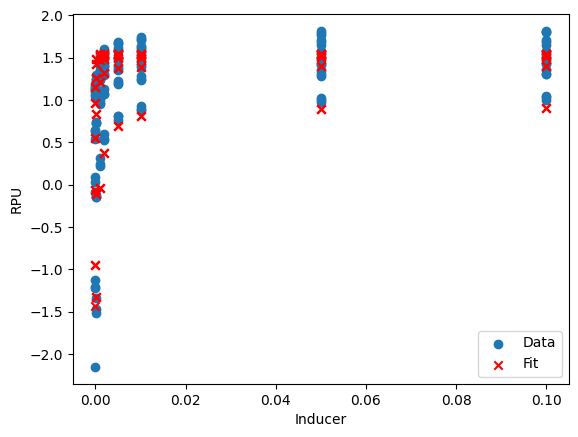

In [40]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import warnings

# 忽略拟合警告
warnings.simplefilter("ignore", np.RankWarning)

# 读取数据
df = pd.read_csv(r'E:\Desktop\BraR.csv')

# 提取数据列并去掉缺失值
L = df['LBD'].dropna().values
I = df['inducer'].dropna().values
P1 = np.log10(df['RPU']).dropna().values

# 固定参数
Imax = 35.84931505
I0 = 0.035485714
kd = 40.97704697

# 定义目标函数
def func(x, k1, k2, k3):
    L, I = x
    # 确保参数为正
    if not (0 < k1 and 0 < k2 and 0 < k3):
        return np.ones_like(L) * 1e10
    x1 = np.sqrt((k2*I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    return np.log10(Imax * ((L / 2) * ((x1 - (k2*I + 1)) / (x1 + (k2*I + 1))) * kd /
                   (1 + (L / 2) * ((x1 - (k2*I + 1)) / (x1 + (k2*I + 1))) * kd)) + I0)

# 初始猜测
p0 = [0.024643659, 0.00000004, 538352547.7]

# 拟合参数，限制参数范围为正
params, pcov = curve_fit(
    func,
    (L, I),
    P1,
    p0=p0,
    bounds=([1e-8, 1e-8, 1e-8], [np.inf, np.inf, np.inf]),
    method='trf',
    maxfev=1000000
)

k1, k2, k3 = params

print('Fitted parameters:')
print('k1 = %.15f' % k1)
print('k2 = %.8f' % k2)
print('k3 = %.15f' % k3)

# 计算拟合值
P1_fit = func((L, I), k1, k2, k3)

# 计算残差平方和
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.6f' % ssr)

# 可选：绘制拟合曲线（如果需要）
import matplotlib.pyplot as plt
plt.scatter(I, P1, label='Data')
plt.scatter(I, P1_fit, label='Fit', color='red', marker='x')
plt.xlabel('Inducer')
plt.ylabel('RPU')
plt.legend()
plt.show()


In [37]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv(r'E:\Desktop\NR2\GR.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = np.log10(df['RPU']).dropna()
I = df['inducer'].dropna()
Imax=35.84931505

I0=0.035485714

kd=40.97704697


# Define the objective function
def func(x, k1, k2, k3,kx1,kx2):
            L,I=x
            if not 0 < k1  or not 0 < k2  or not 0 < k3 or not 0 < kx1  or not 0 < kx2 :
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2 * I + kx1 + kx2 * k2 * I + 1) ** 2 + 8 * L * (k2 * k2 * k3 * I * I + k1 + k1 * kx1 * kx1 + k3 * k2 * k2 * kx2 * kx2 * I * I))
            P1 = (
                Imax
                * ((L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1))) * kd
                / (1 + (L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1))) * kd))
                + I0
            )
            return np.log10(P1)

# Use curve_fit function to fit model parameters
params, pcov = curve_fit(func, (L,I), P1, p0=[0.01,0.1,0.1,1,0.1],maxfev=10000000)

k1, k2, k3 , kx1, kx2 = params
print('k1= %.15f' % k1)
print('k2= %.8f' % k2)
print('k3= %.15f' % k3)
print('kx1= %.15f' % kx1)
print('kx2= %.15f' % kx2)
            
# Compute the fitted curve
P1_fit = func((L,I), k1, k2, k3,kx1,kx2)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

k1= 0.000006511878394
k2= 0.00197499
k3= 0.001810444880760
kx1= 2.686299296972178
kx2= 1.437175533106084
Sum of squared residuals: 11.1890


In [250]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv('E:\Desktop\DBD\\340_without1st.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()
Imax=35.84931505

I0=0.008956896



kd=5.066512585


k2=0.007083518

k3=0.760771692


# Define the objective function
def func(x, k1):
            L,I=x
            if not 0 < k1  :
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)

# Use curve_fit function to fit model parameters
params, pcov = curve_fit(func, (L,I), P1, p0=[0.01],maxfev=10000000)

k1 = params
print('k1= %.15f' % k1)

            
# Compute the fitted curve
P1_fit = func((L,I), k1)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

k1= 0.000776107526976
Sum of squared residuals: 5837.0961


In [260]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv('E:/Desktop/DBD/327.csv')

# Filter rows where inducer == 0
df_zero = df[df['inducer'] == 0].dropna(subset=['LBD', 'RPU'])

# Extract L and P1
L = df_zero['LBD'].values
P1 = df_zero['RPU'].values
I = df_zero['inducer'].values  # I will be all zeros here

Imax = 35.84931505
I0 =0.035485714

kd =40.97704697



# Define the objective function
def func(x, k1):
    L, I = x
    if k1 <= 0:
        return np.ones_like(L) * 1e10
    x1 = np.sqrt(1 + 8 * L * k1)
    y1 = (x1 - 1) / (x1 + 1)
    return Imax * ((L / 2) * y1 * kd / (1 + (L / 2) * y1 * kd)) + I0

# Fit model
params, _ = curve_fit(func, (L, I), P1, p0=[0.01], maxfev=100000)

k1 = params[0]
print('k1 = %.15f' % k1)

# Compute fitted curve and residuals
P1_fit = func((L, I), k1)
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)


k1 = 0.000182163288620
Sum of squared residuals: 12.2491


In [5]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv('E:\Desktop\mamm\\407.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()
Imax=13.60910816
I0=0.126120669




# Define the objective function
def func(x, k1, k2, k3, kd):
            L,I=x
            if not 0 < k1  or not 0 < k2  or not 0 < k3 or not 0 < kd :
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)

# Use curve_fit function to fit model parameters
params, pcov = curve_fit(func, (L,I), P1, p0=[0.1,0.1,0.1,10],maxfev=10000)

k1, k2, k3 , kd= params
print('k1: %.15f' % k1)
print('k2: %.8f' % k2)
print('k3: %.8f' % k3)
print('kd: %.8f' % kd)

            
# Compute the fitted curve
P1_fit = func((L,I), k1, k2, k3,kd)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

k1: 0.000016558208381
k2: 0.00000045
k3: 9133524.29372695
kd: 343.56575409
Sum of squared residuals: 96.3098


In [267]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv('E:\Desktop\data\\337_without1st.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()
Imax=35.84931505

I0=0.01

k1=0.000268715

k2=0.007083518

k3=0.760771692
# Define the objective function
def func(x, kd):
            L,I=x
            if not 0 < kd  :
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd )/( (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd))) + I0

# Use curve_fit function to fit model parameters
params, pcov = curve_fit(func, (L,I), P1, p0=[10.0],maxfev=10000)

kd= params

print('kd: %.8f' % kd)

            
# Compute the fitted curve
P1_fit = func((L,I),kd)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

kd: 1.49687231
Sum of squared residuals: 3491.8696


In [63]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv('E:\Desktop\data\\DBP60.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = np.log10(df['RPU']).dropna()
I = df['inducer'].dropna()
Imax =35.84931505
I0 = 0.13576227
k1=0.000268715

k2=0.007083518

k3=0.760771692

# Define the objective function
def func(x, kd,kd0):
            L,I=x
            if not 0 < kd  or not 0 < kd0 or not kd0<kd  :
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return np.log10(Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * (kd +kd0)/ (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * (kd +kd0))) + I0)

# Use curve_fit function to fit model parameters
params, pcov = curve_fit(func, (L,I), P1, p0=[0.001,0.0001])

kd , kd0= params
print('kd: %.15f' % kd)
print('kd0: %.15f' % kd0)
            
# Compute the fitted curve
P1_fit = func((L,I), kd,kd0)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

kd: 0.001348885249038
kd0: 0.000392818800472
Sum of squared residuals: 37.4598


In [138]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import os

# === 固定已知参数 ===
Imax = 35.84931505
I0 = 0.01
k1 = 0.000268715
k2 = 0.007083518
k3 = 0.760771692
eps = 1e-10  # 防止除0

# === 模型函数 ===
def func(x, kd, kd0):
    L_vals, I_vals = x
    k2I_plus_1 = k2 * I_vals + 1
    sqrt_term = np.sqrt(k2I_plus_1**2 + 8 * L_vals * (k2**2 * k3 * I_vals**2 + k1))
    x1_term = (sqrt_term - k2I_plus_1) / (sqrt_term + k2I_plus_1 + eps)
    
    numerator = (L_vals / 2)**2 * x1_term**2 * kd0 * kd
    denominator = 1 + numerator
    P_pred = Imax * (numerator / (denominator + eps)) + I0
    return P_pred + eps

# === 批量拟合所有 CSV 文件 ===
folder_path = r'E:\Desktop\DBD'  # 修改为你的文件夹路径
output_csv = os.path.join(folder_path, 'fit_results.csv')

results = []
failed_files = []
p0 = [5, 0.01]

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        try:
            df = pd.read_csv(file_path)

            # 确保包含所需列
            if not all(col in df.columns for col in ['LBD', 'inducer', 'RPU']):
                raise ValueError("缺少必要列 LBD, inducer 或 RPU")

            L = df['LBD'].dropna().values
            I = df['inducer'].dropna().values
            P1 = df['RPU'].dropna().values

            # 拟合
            params, _ = curve_fit(func, (L, I), P1, p0=p0, maxfev=5000)
            kd, kd0 = params
            P1_fit = func((L, I), kd, kd0)
            ssr = np.sum((P1 - P1_fit) ** 2)

            results.append({
                'filename': filename,
                'kd': kd,
                'kd0': kd0,
                'SSR': ssr
            })

        except Exception as e:
            failed_files.append((filename, str(e)))
            print(f"❌ Error fitting {filename}: {e}")

# === 保存拟合结果 ===
results_df = pd.DataFrame(results)
results_df.to_csv(output_csv, index=False)
print(f"\n✅ 拟合完成，结果已保存至: {output_csv}")

# === 输出失败文件（可选） ===
if failed_files:
    print("\n⚠️ 以下文件拟合失败：")
    for f, msg in failed_files:
        print(f" - {f}: {msg}")



✅ 拟合完成，结果已保存至: E:\Desktop\DBD\fit_results.csv


In [137]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os

# === 1. 固定已知参数 ===
Imax = 35.84931505
I0 = 0.035485714

k1 = 0.000268715
k2 = 0.007083518
k3 = 0.760771692

# === 2. 模型函数 ===
def model(xdata, kd, kd0):
    L, I = xdata
    x1 = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    theta = (L / 2) * ((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1)))
    f_dbd_dimer = kd0 / (1 + kd0)
    theta_eff = theta * f_dbd_dimer
    P = Imax * (theta_eff * kd / (1 + theta_eff * kd)) + I0
    return P

# === 3. 设置参数 ===
folder_path = 'E:\\Desktop\DBD\\'  # 文件夹路径
output_csv = 'E:\\Desktop\DBD\\fit_results.csv'  # 输出结果路径
p0 = [5.0, 0.1]
bounds = ([0, 0], [1e2, 1])

# === 4. 批量拟合每个CSV文件 ===
results = []
failed_files = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        try:
            df = pd.read_csv(file_path)
            L = df['LBD'].values
            I = df['inducer'].values
            P_obs = df['RPU'].values

            # 拟合
            params, _ = curve_fit(model, (L, I), P_obs, p0=p0, bounds=bounds, maxfev=10000)
            kd_fit, kd0_fit = params
            P_fit = model((L, I), *params)
            ssr = np.sum((P_obs - P_fit) ** 2)

            results.append({
                'filename': filename,
                'kd': kd_fit,
                'kd0': kd0_fit,
                'SSR': ssr
            })
        except Exception as e:
            failed_files.append((filename, str(e)))
            print(f"❌ Error fitting {filename}: {e}")

# === 5. 保存结果到CSV ===
result_df = pd.DataFrame(results)
result_df.to_csv(output_csv, index=False)
print(f"\n✅ 拟合完成，共 {len(results)} 个文件，结果保存至 {output_csv}")

# === 6. 输出出错文件（可选）===
if failed_files:
    print("\n⚠️ 以下文件拟合失败：")
    for f, err in failed_files:
        print(f" - {f}: {err}")



✅ 拟合完成，共 17 个文件，结果保存至 E:\Desktop\DBD\fit_results.csv


总表观希尔系数 n_total = 1.768
kd贡献的希尔系数 ≈ 0.898 （占比 50.80%）
kd0贡献的希尔系数 ≈ 0.870 （占比 49.20%）
贡献和 ≈ 1.768 (接近n_total)


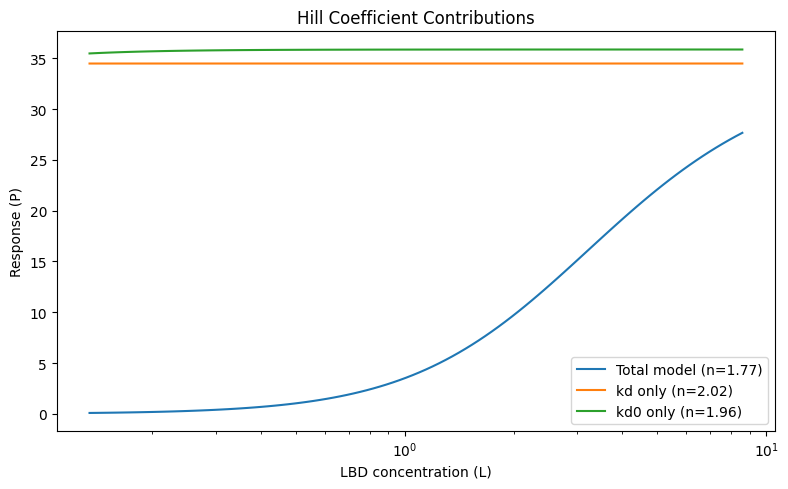

In [130]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- 固定参数 ---
Imax = 35.84931505
I0 = 0.01
k1 = 0.000268715
k2 = 0.007083518
k3 = 0.760771692

# --- 读取数据 ---
df = pd.read_csv("E:\\Desktop\\data\\335_without1st.csv")
L_all = df["LBD"].values
I_all = df["inducer"].values
P_obs = df["RPU"].values

# 选一个固定诱导浓度I（比如中位数）
I_fix = np.median(I_all)

# --- Hill 函数定义（以 L 为自变量，拟合 P）---
def hill_logL(L, n, Kd, baseline, amplitude):
    return baseline + amplitude * (L**n / (Kd**n + L**n))

# --- 模型函数 ---
def model_P(L, kd, kd0, I=I_fix):
    x1 = np.sqrt((k2*I + 1)**2 + 8*L*(k2**2 * k3 * I**2 + k1))
    y = k2*I + 1
    theta = (L/2) * ((x1 - y) / (x1 + y))
    theta_eff = theta * kd0 / (1 + theta * kd0)
    P = Imax * (theta_eff * kd / (1 + theta_eff * kd)) + I0
    return P

# --- 拟合Hill系数函数 ---
def fit_hill_L(L, P):
    p0 = [1, np.median(L), np.min(P), np.max(P)-np.min(P)]
    bounds = ([0, 0, -np.inf, 0], [5, np.inf, np.inf, np.inf])
    popt, _ = curve_fit(hill_logL, L, P, p0=p0, bounds=bounds, maxfev=10000)
    return popt[0]  # 返回拟合的Hill系数n

# --- 先给kd和kd0一个初始值（你可以用拟合或者经验值）---
kd_fit = 25
kd0_fit = 0.1

# --- 生成L范围，避免0值导致log问题 ---
L_range = np.logspace(np.log10(max(min(L_all[L_all>0]), 1e-5)), np.log10(max(L_all)), 100)

# --- 计算对应的P曲线 ---
P_total = model_P(L_range, kd_fit, kd0_fit)
P_kd_only = model_P(L_range, kd_fit, kd0=1e6)      # kd0无效，忽略kd0限制
P_kd0_only = model_P(L_range, kd=1e6, kd0=kd0_fit) # kd无效，忽略kd限制

# --- 拟合希尔系数 ---
n_total = fit_hill_L(L_range, P_total)
n_kd = fit_hill_L(L_range, P_kd_only)
n_kd0 = fit_hill_L(L_range, P_kd0_only)

# --- 计算贡献权重 ---
weight_kd = n_kd / (n_kd + n_kd0)
weight_kd0 = n_kd0 / (n_kd + n_kd0)

# --- 按比例估计贡献 ---
contrib_kd = n_total * weight_kd
contrib_kd0 = n_total * weight_kd0

# --- 输出 ---
print(f"总表观希尔系数 n_total = {n_total:.3f}")
print(f"kd贡献的希尔系数 ≈ {contrib_kd:.3f} （占比 {weight_kd:.2%}）")
print(f"kd0贡献的希尔系数 ≈ {contrib_kd0:.3f} （占比 {weight_kd0:.2%}）")
print(f"贡献和 ≈ {contrib_kd + contrib_kd0:.3f} (接近n_total)")

# --- 画图展示 ---
plt.figure(figsize=(8,5))
plt.plot(L_range, P_total, label=f'Total model (n={n_total:.2f})')
plt.plot(L_range, P_kd_only, label=f'kd only (n={n_kd:.2f})')
plt.plot(L_range, P_kd0_only, label=f'kd0 only (n={n_kd0:.2f})')
plt.xscale('log')
plt.xlabel('LBD concentration (L)')
plt.ylabel('Response (P)')
plt.title('Hill Coefficient Contributions')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# 你的模型函数，输入L和I，返回P
def model_P(L, I, kd, k1, k2, k3, Imax, I0):
    x1 = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    term = (L / 2) * ((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) * kd
    P = np.log10(Imax * (term / (1 + term)) + I0)
    return P

# 计算表观希尔系数
def calc_apparent_hill_coefficient(L_vals, P_vals):
    P_min = np.min(P_vals)
    P_max = np.max(P_vals)
    P_half = (P_max + P_min) / 2

    # 找到EC50，即P接近半最大响应的L值索引
    idx = np.argmin(np.abs(P_vals - P_half))
    EC50 = L_vals[idx]

    # 计算数值导数 dP/dL
    delta = 1 if idx > 0 else 0
    delta = min(delta, len(L_vals)-1 - idx)  # 避免越界
    if delta == 0:
        raise ValueError("数据点太少，无法计算导数")
    dP_dL = (P_vals[idx + delta] - P_vals[idx - delta]) / (L_vals[idx + delta] - L_vals[idx - delta])

    # 计算表观希尔系数 n_app
    # 注意这里用的是原始P，没有减P_min，因为是对log信号的斜率
    n_app = (EC50 / (P_vals[idx] - P_min)) * dP_dL * (P_max - P_min)

    return n_app, EC50

# 例子
# 假设I固定
I_fixed = 1
kd =5.066512585


k1 = 0.000268715
k2 = 0.007083518
k3 = 0.760771692
Imax = 35.84931505
I0 = 0.008956896



# 生成L值，建议log spaced更合理
L_vals = np.logspace(-2, 1, 2000)  # 从0.001到10，100点

P_vals = model_P(L_vals, I_fixed, kd, k1, k2, k3, Imax, I0)

n_app, EC50 = calc_apparent_hill_coefficient(L_vals, P_vals)

print(f"表观希尔系数 n_app = {n_app:.3f}， EC50 = {EC50:.5f}")


表观希尔系数 n_app = 1.652， EC50 = 1.89731


In [86]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv('E:\Desktop\mamm\\541.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()
Imax = 13.60910816
I0 = 0.013
k1 = 0.001602443364710
k2 = 0.001524222858930
k3 = 0.182147637032712

# Define the objective function
def func(x, kd):
            L,I=x
            if not 0 < kd :
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * (kd)/ (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * (kd))) + I0)

# Use curve_fit function to fit model parameters
params, pcov = curve_fit(func, (L,I), P1, p0=[1])

kd = params
print('kd: %.15f' % kd)

            
# Compute the fitted curve
P1_fit = func((L,I), kd)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

kd: 0.207621950121747
Sum of squared residuals: 0.3665


In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv(r'E:\Desktop\all_data\data8\BjaRmut.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 =(df['RPU']).dropna()
I = df['inducer'].dropna()

# 固定参数
I0 = 0.006969286




Imax = 35.84931505



kd =1.13083303




# 使用您的原始函数
def func(x, k1, k2, k3):
    L, I = x
    if not 0 < k1 < 10 or not 0 < k2 or not 0 < k3:
        return np.ones_like(L) * 1e10  # 返回一个大的值
    x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
    return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * (kd)/ (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * (kd))) + I0)

# 使用边界约束而不是函数内检查
bounds = ([1e-20, 1e-15, 1e-15], [1000, 1000000000000, 100000000000000000000000])

# 使用 curve_fit 函数拟合模型参数
try:
    params, pcov = curve_fit(func, (L, I), P1, 
                           p0=[0.1, 0.1, 0.1], 
                           bounds=bounds, 
                           maxfev=1000000000)
    
    k1, k2, k3 = params
    print('k1 = %.15f' % k1)
    print('k2 = %.15f' % k2)
    print('k3 = %.15f' % k3)
    
    # 计算拟合曲线
    P1_fit = func((L, I), k1, k2, k3)
    
    # 计算残差平方和
    residuals = P1 - P1_fit
    ssr = np.sum(residuals ** 2)
    print('残差平方和: %.4f' % ssr)
    
    # 计算R²
    ss_tot = np.sum((P1 - np.mean(P1)) ** 2)
    r_squared = 1 - (ssr / ss_tot)
    print('R²: %.4f' % r_squared)
    
except Exception as e:
    print(f"拟合失败: {e}")
    # 如果使用边界约束失败，回退到原始方法
    print("尝试使用无边界约束的拟合...")
    params, pcov = curve_fit(func, (L, I), P1, p0=[0.1, 0.1, 0.1], maxfev=9000000000)
    
    k1, k2, k3 = params
    print('k1 = %.15f' % k1)
    print('k2 = %.15f' % k2)
    print('k3 = %.15f' % k3)
    
    # 计算拟合曲线
    P1_fit = func((L, I), k1, k2, k3)
    
    # 计算残差平方和
    residuals = P1 - P1_fit
    ssr = np.sum(residuals ** 2)
    print('残差平方和: %.4f' % ssr)
    
    # 计算R²
    ss_tot = np.sum((P1 - np.mean(P1)) ** 2)
    r_squared = 1 - (ssr / ss_tot)
    print('R²: %.4f' % r_squared)

k1 = 0.000440411855248
k2 = 0.007141061733050
k3 = 0.174968795780096
残差平方和: 550.4559
R²: 0.9585


In [134]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv(r'E:\Desktop\mamm\540.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()

# 固定参数
I0 = 0.014
Imax = 13.60910816


k1 = 0.000321472093614
k2 = 0.001660055396366
k3 = 0.010506853783581
# 修改函数，只拟合kd参数
def func(x, kd):
    L, I = x
    
    # 使用已知的k1,k2,k3
    x1 = np.sqrt((k2*I+1)*(k2*I+1) + 8 * L * (k2*k2*k3*I*I + k1))
    
    # 计算返回值
    ratio = (x1 - (k2*I+1)) / (x1 + (k2*I+1))
    numerator = (L / 2) * ratio * kd
    denominator = 1 + (L / 2) * ratio * kd
    
    return Imax * (numerator / denominator) + I0

# 使用边界约束
bounds = ([1e-6], [100000])  # kd的范围

# 使用 curve_fit 函数拟合kd参数
try:
    params, pcov = curve_fit(func, (L, I), P1, 
                           p0=[1.0],  # kd的初始猜测值
                           bounds=bounds, 
                           maxfev=1000000000)
    
    kd_fit = params[0]
    print('拟合得到的 kd = %.15f' % kd_fit)
    
    # 计算拟合曲线
    P1_fit = func((L, I), kd_fit)
    
    # 计算残差平方和
    residuals = P1 - P1_fit
    ssr = np.sum(residuals ** 2)
    print('残差平方和: %.4f' % ssr)
    
    # 计算R²
    ss_tot = np.sum((P1 - np.mean(P1)) ** 2)
    r_squared = 1 - (ssr / ss_tot)
    print('R²: %.4f' % r_squared)
    
except Exception as e:
    print(f"拟合失败: {e}")
    # 如果使用边界约束失败，回退到原始方法
    print("尝试使用无边界约束的拟合...")
    params, pcov = curve_fit(func, (L, I), P1, 
                           p0=[10],  # kd的初始猜测值
                           maxfev=1000000000)
    
    kd_fit = params[0]
    print('拟合得到的 kd = %.15f' % kd_fit)
    
    # 计算拟合曲线
    P1_fit = func((L, I), kd_fit)
    
    # 计算残差平方和
    residuals = P1 - P1_fit
    ssr = np.sum(residuals ** 2)
    print('残差平方和: %.4f' % ssr)
    
    # 计算R²
    ss_tot = np.sum((P1 - np.mean(P1)) ** 2)
    r_squared = 1 - (ssr / ss_tot)
    print('R²: %.4f' % r_squared)

拟合得到的 kd = 10.568261291863552
残差平方和: 2.3175
R²: 0.9608


In [290]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv(r'E:\Desktop\mamm\414.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()

# 固定参数
I0 = 0.064825979



Imax = 13.60910816
kd = 9.152591138





# 精确按照您提供的公式
def func(x, k1, k2, k3, kx1, kx2):
    L, I = x
    
    # 参数边界检查
    if not 0 < k1  or not 0 < k2 or not 0 < k3 or not 0 < kx1 or not 0 < kx2:
        return np.ones_like(L) * 1e10
    
    # 计算 x1
    term = k2*I + kx1 + kx2*k2*I + 1
    x1 = np.sqrt(term*term + 8 * L * (k2*k2*k3*I*I + k1 + k1*kx1*kx1 + k3*k2*k2*kx2*kx2*I*I))
    
    # 计算返回值
    ratio = (x1 - term) / (x1 + term)
    numerator = (L / 2) * ratio * kd
    denominator = 1 + (L / 2) * ratio * kd
    
    return Imax * (numerator / denominator) + I0

# 使用 curve_fit 函数拟合模型参数
params, pcov = curve_fit(func, (L, I), P1, 
                       p0=[0.001, 1, 1000000, 10, 10], 
                       maxfev=1000000000)

k1, k2, k3, kx1, kx2 = params
print('k1 = %.15f' % k1)
print('k2 = %.15f' % k2)
print('k3 = %.15f' % k3)
print('kx1 = %.15f' % kx1)
print('kx2 = %.15f' % kx2)

# 计算拟合曲线
P1_fit = func((L, I), k1, k2, k3, kx1, kx2)

# 计算残差平方和
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('残差平方和: %.4f' % ssr)

# 计算R²
ss_tot = np.sum((P1 - np.mean(P1)) ** 2)
r_squared = 1 - (ssr / ss_tot)
print('R²: %.4f' % r_squared)

k1 = 0.001219930339093
k2 = 0.086482392930050
k3 = 201.231136940868225
kx1 = 20.182551524392508
kx2 = 0.000774373147716
残差平方和: 33.7926
R²: 0.5222


In [249]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv(r'E:\Desktop\mamm\408.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()

# 固定参数
I0 = 0.103478333


Imax = 13.60910816

# 已知的参数值（请替换为您的实际值）
k1 = 0.000000000819018
k2 = 0.057153100961834
k3 = 0.216482538234428
kx1 = 13.611964046707675
kx2 = 56.785136987362208


# 精确按照您提供的公式，只拟合kd
def func(x, kd):
    L, I = x
    
    # 使用已知的k1,k2,k3,kx1,kx2
    x1 = np.sqrt((k2*I+kx1+kx2*k2*I+1)*(k2*I+kx1+kx2*k2*I+1) + 8 * L * (k2*k2*k3*I*I + k1+k1*kx1*kx1+k3*k2*k2*kx2*kx2*I*I))
    
    # 计算返回值
    term = k2*I+kx1+kx2*k2*I+1
    ratio = (x1 - term) / (x1 + term)
    numerator = (L / 2) * ratio * kd
    denominator = 1 + (L / 2) * ratio * kd
    
    return Imax * (numerator / denominator) + I0

# 使用curve_fit函数拟合kd参数
params, pcov = curve_fit(func, (L, I), P1, 
                       p0=[20.0],  # kd的初始猜测值
                       maxfev=1000000)

kd_fit = params[0]
print('拟合得到的 kd = %.15f' % kd_fit)

# 计算拟合曲线
P1_fit = func((L, I), kd_fit)

# 计算残差平方和
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('残差平方和: %.4f' % ssr)

# 计算R²
ss_tot = np.sum((P1 - np.mean(P1)) ** 2)
r_squared = 1 - (ssr / ss_tot)
print('R²: %.4f' % r_squared)

拟合得到的 kd = 49.148232813460957
残差平方和: 223.1997
R²: 0.5918


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv(r'E:\Desktop\model\crosstalk4\\368_C12.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()
Imax=35.84931505

I0=0.272291827


kd=10.53282547

k1= 0.010042600398181
k2= 0.459416965988916



# Define the objective function
def func(x, k3):
            L,I=x
            if not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * (kd)/ (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * (kd))) + I0)

# Use curve_fit function to fit model parameters
params, pcov = curve_fit(func, (L,I), P1, p0=[0.1], maxfev = 1000000000)

k3 = params


print('k3= %.15f' % k3)

            
# Compute the fitted curve
P1_fit = func((L,I), k3)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

k3= 0.099933099348155
Sum of squared residuals: 54.5983


In [15]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit


# Read the data
df = pd.read_csv('E:\Desktop\mamm\\409.csv')

# Extract the required data columns
L = df['LBD'].dropna()
P1 = (df['RPU']).dropna()
I = df['inducer'].dropna()
k1= 4.68825E-10

k2= 0.81679679

k3= 1.08611216

kx1= 0.895304788

kx2= 0.113015736
Imax=13.60910816

I0=0.01



# Define the objective function
def func(x, kd):
            L,I=x
            if not 0 < kd:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+kx1+kx2*k2*I+1)*(k2*I+kx1+kx2*k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1+k1*kx1*kx1+k3*k2*k2*kx2*kx2*I*I))
            return (Imax * ((L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) * kd / (1 + (L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) *kd)) + I0)
    
# Use curve_fit function to fit model parameters
params, pcov = curve_fit(func, (L,I), P1, p0=[15])

kd= params
print('kd: %.15f' % kd)

            
# Compute the fitted curve
P1_fit = func((L,I), kd)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

kd: 1.227966131497620
Sum of squared residuals: 58.8952


In [11]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv(r"E:\Desktop\all_data\crosstalk_new\s5_ER_DHB_2nd.csv")


# Extract the required data columns
L = df['LBD'].dropna()
P1 = np.log10(df['RPU']).dropna()
I = df['inducer'].dropna()

Imax= 35.84931505

I0= 0.035485714
k1= 6.353E-12



k2=3.583382137



kd =40.97704697


# Define the objective function
def func(x,k3,kx1,kx2):
            L,I=x
            if  not k3>0 or not kx2>0 or not kx1>0 :
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+kx1+kx2*k2*I+1)*(k2*I+kx1+kx2*k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1+k1*kx1*kx1+k3*k2*k2*kx2*kx2*I*I))
            return np.log10(Imax * ((L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) * kd / (1 + (L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) *kd)) + I0)
    
# Use curve_fit function to fit model parameters

params, pcov = curve_fit(func, (L,I), P1, p0=[0.1,0.1,0.1], maxfev = 1000000000)

k3,kx1,kx2= params
            
# Compute the fitted curve
P1_fit = func((L,I), k3,kx1,kx2)

print('k3= %.15f' % k3)
print('kx1= %.15f' % kx1)
print('kx2= %.15f' % kx2)
# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

k3= 0.002820379874017
kx1= 90.438632354216338
kx2= 0.000010055243956
Sum of squared residuals: 2.2324


In [75]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Read the data
df = pd.read_csv(r"E:\Desktop\\330_new_0.csv")


# Extract the required data columns
L = df['LBD'].dropna()
P1 = np.log10(df['RPU']).dropna()
I = df['inducer'].dropna()

Imax= 35.84931505

I0= 0.035485714
kd =40.97704697

# Define the objective function
def func(x, k1,kx1):
            L,I=x
            if not 0 < k1 or not k2>0 or not k3>0 or not kx1>0 or not kx2>0:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((kx1+1)*(kx1+1)+ 8 * L * (k1+k1*kx1*kx1))
            return np.log10(Imax * ((L / 2) * ((x1 -  (kx1+1)) / (x1 +  (kx1+1))) * kd / (1 + (L / 2) * ((x1 -  (kx1+1)) / (x1 +  (kx1+1))) *kd)) + I0)
    
# Use curve_fit function to fit model parameters

params, pcov = curve_fit(func, (L,I), P1, p0=[0.1,0.001], maxfev = 1000000000)

k1,kx1= params
            
# Compute the fitted curve
P1_fit = func((L,I), k1,kx1)
print('k1= %.15f' % k1)

print('kx1= %.15f' % kx1)

# Calculate the sum of squared residuals
residuals = P1 - P1_fit
ssr = np.sum(residuals ** 2)
print('Sum of squared residuals: %.4f' % ssr)

k1= 0.000007063738052
kx1= 0.798527188158513
Sum of squared residuals: 2.1439


In [189]:
import numpy as np
import pandas as pd
import os
from scipy.optimize import curve_fit
import glob

def model_func(L, I, I0, Imax, k1, k2, k3, kx1, kx2, kd):
    # 所有参数都视为正值
    k1, k2, k3, kx1, kx2, kd = map(abs, [k1, k2, k3, kx1, kx2, kd])
    kx2 = max(kx2, 0.001)
    x1 = np.sqrt((k2 * I + kx1 + kx2 * k2 * I + 1)**2 +
                 8 * L * (k2**2 * k3 * I**2 + k1 + k1 * kx1**2 + k3 * k2**2 * kx2**2 * I**2))
    term = (L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1)))
    return (Imax * term * kd / (1 + term * kd)) + I0

# -------------------- 1. 合并数据拟合共享参数 -----------------------
folder_path = "E:/Desktop/mamm/DHBR"
I0 = 0.049378964
Imax = 13.60910816

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
I_all, L_all, y_all = [], [], []

valid_data = {}
for file in csv_files:
    df = pd.read_csv(file).dropna(subset=["inducer", "LBD", "RPU"])
    if not df.empty:
        I_all.extend(df["inducer"].values)
        L_all.extend(df["LBD"].values)
        y_all.extend(df["RPU"].values)
        valid_data[file] = df
    else:
        print(f"⚠️ 跳过空文件：{os.path.basename(file)}")

if not valid_data:
    raise RuntimeError("❗ 所有 CSV 文件都无有效数据，无法拟合")

I_all, L_all, y_all = map(np.array, (I_all, L_all, y_all))

# 拟合共享参数（k1–kx2），kd 暂时也一起拟合，但只用前5个参数
def merged_model(IL, k1, k2, k3, kx1, kx2, kd):
    I, L = IL
    return model_func(L, I, I0, Imax, k1, k2, k3, kx1, kx2, kd)

p0 = [1, 1.0, 1.0, 0.1,1.0, 1000.0]  # 初始猜测值
bounds = (0, 10000000000)  # 所有参数强制为正

popt_all, _ = curve_fit(
    merged_model,
    (I_all, L_all),
    y_all,
    p0=p0,
    bounds=bounds,
    maxfev=500000000
)
k1, k2, k3, kx1, kx2, _ = popt_all  # 最后一个 kd 丢弃，只保留共享参数

print("✅ 全局共享参数拟合结果：")
print(f"k1 = {k1:.15f}, k2 = {k2:.6f}, k3 = {k3:.6f}, kx1 = {kx1:.6f}, kx2 = {kx2:.6f}")

# -------------------- 2. 每个文件拟合单独 kd -----------------------
kd_dict = {}
for file, df in valid_data.items():
    I, L, y = df["inducer"].values, df["LBD"].values, df["RPU"].values

    def kd_model(I, kd):
        return model_func(L, I, I0, Imax, k1, k2, k3, kx1, kx2, kd)

    popt_kd, _ = curve_fit(kd_model, I, y, p0=[1.0], bounds=([1e-5], [1000]), maxfev=20000)
    kd_dict[file] = popt_kd[0]

# -------------------- 输出拟合结果 -----------------------
print("\n📄 每个文件的 kd 拟合值：")
for f, kd in kd_dict.items():
    print(f"{os.path.basename(f)}: kd = {kd:.4f}")


✅ 全局共享参数拟合结果：
k1 = 0.000000000000000, k2 = 0.000300, k3 = 1803328323.724383, kx1 = 9.264994, kx2 = 0.000890

📄 每个文件的 kd 拟合值：
408.csv: kd = 3.2285
409.csv: kd = 0.6176


In [336]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import glob

def fit_shared_k1k2k3_and_individual_kd(file_pattern, I0, Imax):
    # 获取所有数据文件
    file_list = glob.glob(file_pattern)
    
    if not file_list:
        print("未找到匹配的文件")
        return
    
    # 第一阶段：收集所有数据
    all_L, all_P1, all_I = [], [], []
    for file_path in file_list:
        df = pd.read_csv(file_path)
        L = df['LBD'].dropna()
        P1 = np.log10(df['RPU']).dropna()
        I = df['inducer'].dropna()
        
        all_L.extend(L.values)
        all_P1.extend(P1.values)
        all_I.extend(I.values)
    
    all_L = np.array(all_L)
    all_P1 = np.array(all_P1)
    all_I = np.array(all_I)
    
    # 模型函数
    def func(x, k1, k2, k3, kd):
        L, I = x
        x1 = np.sqrt((k2*I+1)*(k2*I+1) + 8 * L * (k2*k2*k3*I*I + k1))
        ratio = (x1 - (k2*I+1)) / (x1 + (k2*I+1))
        numerator = (L / 2) * ratio * kd
        denominator = 1 + (L / 2) * ratio * kd
        return np.log10(Imax * (numerator / denominator) + I0)
    
    # 拟合共享参数
    bounds = ([1e-6, 1e-6, 1e-6, 1e-6], [1000, 1000000000000, 100000000000000000000000, 1000])
    params, _ = curve_fit(func, (all_L, all_I), all_P1, 
                         p0=[0.1, 100, 0.1, 100], 
                         bounds=bounds, 
                         maxfev=1000000000)
    
    k1_shared, k2_shared, k3_shared, kd_avg = params
    
    # 第二阶段：为每个文件拟合kd
    file_kd_results = {}
    for file_path in file_list:
        df = pd.read_csv(file_path)
        L = df['LBD'].dropna()
        P1 = np.log10(df['RPU']).dropna()
        I = df['inducer'].dropna()
        
        def func_kd_only(x, kd):
            L, I = x
            x1 = np.sqrt((k2_shared*I+1)*(k2_shared*I+1) + 8 * L * (k2_shared*k2_shared*k3_shared*I*I + k1_shared))
            ratio = (x1 - (k2_shared*I+1)) / (x1 + (k2_shared*I+1))
            numerator = (L / 2) * ratio * kd
            denominator = 1 + (L / 2) * ratio * kd
            return Imax * (numerator / denominator) + I0
        
        kd_params, _ = curve_fit(func_kd_only, (L, I), P1, 
                               p0=[kd_avg], 
                               bounds=([1e-6], [1000]), 
                               maxfev=1000000)
        
        file_kd_results[file_path] = kd_params[0]
    
    return k1_shared, k2_shared, k3_shared, file_kd_results

# 使用示例
I0 = 0.014
Imax = 13.60910816
file_pattern = r'E:\Desktop\mamm\TraR\*.csv'  # 根据实际情况调整

k1, k2, k3, kd_results = fit_shared_k1k2k3_and_individual_kd(file_pattern, I0, Imax)

print("共享参数:")
print(f"k1 = {k1:.15f}")
print(f"k2 = {k2:.15f}")
print(f"k3 = {k3:.15f}")

print("\n各文件的kd值:")
for file_path, kd in kd_results.items():
    print(f"{file_path}: kd = {kd:.15f}")

共享参数:
k1 = 0.001478903485184
k2 = 0.000928174545069
k3 = 75.505790936016439

各文件的kd值:
E:\Desktop\mamm\TraR\410.csv: kd = 0.017372227079575
E:\Desktop\mamm\TraR\540.csv: kd = 0.022181496536866
E:\Desktop\mamm\TraR\541.csv: kd = 0.000001000000901


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 读取单个文件
file_path = r"E:/Desktop/mamm/414.csv"
df = pd.read_csv(file_path).dropna(subset=["inducer", "LBD", "RPU"])

# 提取数据
I = df["inducer"].values
L = df["LBD"].values
y = np.log10(df["RPU"].values)

# 常量
I0 = 0.064825979

Imax = 13.60910816
kd = 9.152591138

# 模型函数
def model_func(IL, k1, k2, k3, kx1, kx2):
    I, L = IL
    k1, k2, k3, kx1, kx2 = map(abs, [k1, k2, k3, kx1, kx2])
    kx2 = max(kx2, 0.001)
    x1 = np.sqrt((k2 * I + kx1 + kx2 * k2 * I + 1)**2 +
                 8 * L * (k2**2 * k3 * I**2 + k1 + k1 * kx1**2 + k3 * k2**2 * kx2**2 * I**2))
    term = (L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1)))
    return np.log10((Imax * term * kd / (1 + term * kd)) + I0)

# 初始猜测值和边界
p0 = [1, 100, 1000, 100, 100]
bounds = (0.00000000001, 10000000000)

# 拟合
popt, _ = curve_fit(model_func, (I, L), y, p0=p0, bounds=bounds, maxfev=500000000)
k1, k2, k3, kx1, kx2= popt

# 拟合结果预测值
y_pred = model_func((I, L), *popt)

# R² 计算
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

# 打印参数
print("✅ 拟合参数：")
print(f"k1 = {k1:.15f}")
print(f"k2 = {k2:.6f}")
print(f"k3 = {k3:.6f}")
print(f"kx1 = {kx1:.6f}")
print(f"kx2 = {kx2:.6f}")
print(f"\n📈 R² = {r2:.4f}")


✅ 拟合参数：
k1 = 0.000248746185157
k2 = 125366.224074
k3 = 0.112575
kx1 = 4849.638338
kx2 = 5.573904

📈 R² = 0.9069


In [8]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os
import glob

# 文件夹路径
folder_path = r"E:/Desktop/mamm/DHBR"
file_pattern = os.path.join(folder_path, "*.csv")
file_paths = glob.glob(file_pattern)

# 存储所有数据
all_data = []

# 读取所有文件
for file_path in file_paths:
    df = pd.read_csv(file_path).dropna(subset=["inducer", "LBD", "RPU"])
    df['file_id'] = len(all_data)  # 为每个文件分配唯一ID
    all_data.append(df)

# 合并所有数据
combined_df = pd.concat(all_data, ignore_index=True)

# 提取数据
I = combined_df["inducer"].values
L = combined_df["LBD"].values
y = np.log10(combined_df["RPU"].values)
file_ids = combined_df["file_id"].values  # 文件标识符

# 常量
I0 = 0.020442359

Imax = 13.60910816

# 模型函数 - 现在包含文件特定的kd
def model_func(IL_file, k1, k2, k3, kx1, kx2, *kd_params):
    I, L, file_id = IL_file
    k1, k2, k3, kx1, kx2 = map(abs, [k1, k2, k3, kx1, kx2])
    kx2 = max(kx2, 0.001)
    
    # 为每个数据点选择对应的kd
    kd_array = np.array([kd_params[int(fid)] for fid in file_id])
    
    x1 = np.sqrt((k2 * I + kx1 + kx2 * k2 * I + 1)**2 +
                 8 * L * (k2**2 * k3 * I**2 + k1 + k1 * kx1**2 + k3 * k2**2 * kx2**2 * I**2))
    term = (L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1)))
    
    return np.log10((Imax * term * kd_array / (1 + term * kd_array)) + I0)

# 初始猜测值和边界
n_files = len(all_data)
p0 = [0.01, 10000, 10, 10, 10] + [1000] * n_files  # 共享参数 + 每个文件的kd
bounds_lower = [0.000000000000001] * (5 + n_files)
bounds_upper = [100000000000000] * (5 + n_files)
bounds = (bounds_lower, bounds_upper)

# 拟合
print(f"正在拟合 {n_files} 个文件...")
popt, pcov = curve_fit(model_func, (I, L, file_ids), y, p0=p0, bounds=bounds, maxfev=500000000)

# 提取参数
k1, k2, k3, kx1, kx2 = popt[:5]
kd_params = popt[5:]

# 打印共享参数
print("\n✅ 共享拟合参数：")
print(f"k1 = {k1:.15f}")
print(f"k2 = {k2:.6f}")
print(f"k3 = {k3:.6f}")
print(f"kx1 = {kx1:.6f}")
print(f"kx2 = {kx2:.6f}")

# 打印每个文件的kd
print("\n📊 各文件kd参数：")
for i, file_path in enumerate(file_paths):
    file_name = os.path.basename(file_path)
    print(f"{file_name}: kd = {kd_params[i]:.6f}")

# 计算总体R²
y_pred = model_func((I, L, file_ids), *popt)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2_total = 1 - (ss_res / ss_tot)
print(f"\n📈 总体 R² = {r2_total:.4f}")

# 计算每个文件的R²
print("\n📈 各文件R²：")
for i, file_path in enumerate(file_paths):
    file_name = os.path.basename(file_path)
    mask = file_ids == i
    y_file = y[mask]
    y_pred_file = y_pred[mask]
    ss_res_file = np.sum((y_file - y_pred_file)**2)
    ss_tot_file = np.sum((y_file - np.mean(y_file))**2)
    r2_file = 1 - (ss_res_file / ss_tot_file) if ss_tot_file != 0 else 0
    print(f"{file_name}: R² = {r2_file:.4f}")


正在拟合 2 个文件...

✅ 共享拟合参数：
k1 = 0.001130407548903
k2 = 630.956055
k3 = 0.694748
kx1 = 1.445437
kx2 = 1.242608

📊 各文件kd参数：
408.csv: kd = 122.107758
409.csv: kd = 48.552087

📈 总体 R² = -1.2015

📈 各文件R²：
408.csv: R² = -0.9879
409.csv: R² = -2.0481


In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os
import glob

# 文件夹路径
folder_path = r"E:/Desktop/mamm/MR"
file_pattern = os.path.join(folder_path, "*.csv")
file_paths = glob.glob(file_pattern)

# 存储所有数据
all_data = []

# 读取所有文件
for file_path in file_paths:
    df = pd.read_csv(file_path).dropna(subset=["inducer", "LBD", "RPU"])
    df['file_id'] = len(all_data)  # 为每个文件分配唯一ID
    all_data.append(df)

# 合并所有数据
combined_df = pd.concat(all_data, ignore_index=True)

# 提取数据
I = combined_df["inducer"].values
L = combined_df["LBD"].values
y = np.log10(combined_df["RPU"].values)
file_ids = combined_df["file_id"].values  # 文件标识符

# 常量
I0 = 0.064825979

Imax = 13.60910816

# 固定kd的模型函数
def model_func_fixed_kd(IL_file, k1, k2, k3, kx1, kx2):
    I, L, file_id = IL_file
    k1, k2, k3, kx1, kx2 = map(abs, [k1, k2, k3, kx1, kx2])
    kx2 = max(kx2, 0.001)
    
    # 固定kd值：408.csv (file_id=0) 使用17，409.csv (file_id=1) 使用10
    kd_array = np.array([9.152591138 if fid == 0 else 0.527880511 for fid in file_id])
    
    x1 = np.sqrt((k2 * I + kx1 + kx2 * k2 * I + 1)**2 +
                 8 * L * (k2**2 * k3 * I**2 + k1 + k1 * kx1**2 + k3 * k2**2 * kx2**2 * I**2))
    term = (L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1)))
    
    return np.log10((Imax * term * kd_array / (1 + term * kd_array)) + I0)

# 初始猜测值和边界 - 只拟合5个共享参数
p0 = [0.01, 100, 0.1, 10, 10]
bounds_lower = [0.00000000000000001, 0.000000001, 0.00000000001, 0.000000001, 0.0000000001]
bounds_upper = [1000000000000, 10000000, 100000000000, 10000000000, 10000000000000]
bounds = (bounds_lower, bounds_upper)

# 拟合固定kd模型
print(f"正在拟合 {len(file_paths)} 个文件（固定kd模式）...")
print("固定kd值：414.csv = 9.152591138, 415.csv = 10.56826129")

try:
    popt_fixed, pcov_fixed = curve_fit(model_func_fixed_kd, (I, L, file_ids), y, 
                                      p0=p0, bounds=bounds, maxfev=500000000)
    
    # 提取参数
    k1, k2, k3, kx1, kx2 = popt_fixed
    
    # 打印共享参数
    print("\n✅ 固定kd拟合的共享参数：")
    print(f"k1 = {k1:.15f}")
    print(f"k2 = {k2:.6f}")
    print(f"k3 = {k3:.6f}")
    print(f"kx1 = {kx1:.6f}")
    print(f"kx2 = {kx2:.6f}")
    
    # 打印固定的kd值
    print("\n📊 固定kd参数：")
    for i, file_path in enumerate(file_paths):
        file_name = os.path.basename(file_path)
        kd_value = 9.152591138 if i == 0 else 0.527880511

        print(f"{file_name}: kd = {kd_value:.6f} (固定)")
    
    # 计算总体R²
    y_pred = model_func_fixed_kd((I, L, file_ids), *popt_fixed)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2_total = 1 - (ss_res / ss_tot)
    print(f"\n📈 总体 R² = {r2_total:.4f}")
    
    # 计算每个文件的R²
    print("\n📈 各文件R²：")
    for i, file_path in enumerate(file_paths):
        file_name = os.path.basename(file_path)
        mask = file_ids == i
        y_file = y[mask]
        y_pred_file = y_pred[mask]
        ss_res_file = np.sum((y_file - y_pred_file)**2)
        ss_tot_file = np.sum((y_file - np.mean(y_file))**2)
        r2_file = 1 - (ss_res_file / ss_tot_file) if ss_tot_file != 0 else 0
        kd_value = 9.152591138 if i == 0 else 0.527880511

        print(f"{file_name}: kd = {kd_value:.1f}, R² = {r2_file:.4f}")
    
    
except Exception as e:
    print(f"拟合过程中出现错误: {e}")
    print("尝试调整初始参数或边界条件...")
    
    # 提供备选初始参数
    alternative_p0 = [
        [0.000000001, 0.001, 800000, 8000, 3000],
        [0.00000000001, 0.0005, 400000, 4000, 1500],
        [0.0000000001, 0.0008, 600000, 6000, 2500]
    ]
    
    print("可以尝试的备选初始参数：")
    for i, p0_alt in enumerate(alternative_p0):
        print(f"备选 {i+1}: {p0_alt}")

正在拟合 2 个文件（固定kd模式）...
固定kd值：414.csv = 9.152591138, 415.csv = 10.56826129

✅ 固定kd拟合的共享参数：
k1 = 0.000484948812975
k2 = 58.409860
k3 = 0.048409
kx1 = 1.075915
kx2 = 5.632310

📊 固定kd参数：
414.csv: kd = 9.152591 (固定)
415.csv: kd = 0.527881 (固定)

📈 总体 R² = 0.8746

📈 各文件R²：
414.csv: kd = 9.2, R² = 0.8786
415.csv: kd = 0.5, R² = 0.7192


In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os
import glob

# 文件夹路径
folder_path = r"E:/Desktop/mamm/MR"
file_pattern = os.path.join(folder_path, "*.csv")
file_paths = glob.glob(file_pattern)

# 存储所有数据
all_data = []

# 读取所有文件
for file_path in file_paths:
    df = pd.read_csv(file_path).dropna(subset=["inducer", "LBD", "RPU"])
    df['file_id'] = len(all_data)  # 为每个文件分配唯一ID
    all_data.append(df)

# 合并所有数据
combined_df = pd.concat(all_data, ignore_index=True)

# 提取数据
I = combined_df["inducer"].values
L = combined_df["LBD"].values
y = np.log10(combined_df["RPU"].values)
file_ids = combined_df["file_id"].values  # 文件标识符

# 常量
I0 = 0.046534891

Imax = 13.60910816

# 固定kd的模型函数 - 处理三个文件
def model_func_fixed_kd(IL_file, k1, k2, k3, kx1, kx2):
    I, L, file_id = IL_file
    k1, k2, k3, kx1, kx2 = map(abs, [k1, k2, k3, kx1, kx2])
    kx2 = max(kx2, 0.001)
    
    # 为每个文件分配固定的kd值
    kd_array = np.zeros_like(file_id, dtype=float)
    for i, fid in enumerate(file_id):
        if fid == 0:
            kd_array[i] = 2.09409  # 第一个文件的kd
        elif fid == 1:
            kd_array[i] = 9.152591138  # 第二个文件的kd
        else:
            kd_array[i] = 0.527880511  # 第三个文件的kd
    
    x1 = np.sqrt((k2 * I + kx1 + kx2 * k2 * I + 1)**2 +
                 8 * L * (k2**2 * k3 * I**2 + k1 + k1 * kx1**2 + k3 * k2**2 * kx2**2 * I**2))
    term = (L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1)))
    
    return np.log10((Imax * term * kd_array / (1 + term * kd_array)) + I0)

# 初始猜测值和边界 - 只拟合5个共享参数
p0 = [0.1, 1000000, 1, 1, 10]
bounds_lower = [0.00000000000000001, 0.000001, 0.00001, 0.000001, 0.000001]
bounds_upper = [1000000000000, 10000000000, 100000000000, 10000000000, 10000000000000]
bounds = (bounds_lower, bounds_upper)

# 拟合固定kd模型
print(f"正在拟合 {len(file_paths)} 个文件（固定kd模式）...")
print("固定kd值：")
for i, file_path in enumerate(file_paths):
    file_name = os.path.basename(file_path)
    if i == 0:
        kd_value = 2.09409
    elif i == 1:
        kd_value = 9.152591138
    else:
        kd_value = 0.527880511
    print(f"{file_name}: kd = {kd_value:.6f}")

try:
    popt_fixed, pcov_fixed = curve_fit(model_func_fixed_kd, (I, L, file_ids), y, 
                                      p0=p0, bounds=bounds, maxfev=500000000)
    
    # 提取参数
    k1, k2, k3, kx1, kx2 = popt_fixed
    
    # 打印共享参数
    print("\n✅ 固定kd拟合的共享参数：")
    print(f"k1 = {k1:.15f}")
    print(f"k2 = {k2:.6f}")
    print(f"k3 = {k3:.6f}")
    print(f"kx1 = {kx1:.6f}")
    print(f"kx2 = {kx2:.6f}")
    
    # 打印固定的kd值
    print("\n📊 固定kd参数：")
    for i, file_path in enumerate(file_paths):
        file_name = os.path.basename(file_path)
        if i == 0:
            kd_value = 2.09409
        elif i == 1:
            kd_value = 9.152591138
        else:
            kd_value = 0.527880511

        print(f"{file_name}: kd = {kd_value:.6f} (固定)")
    
    # 计算总体R²
    y_pred = model_func_fixed_kd((I, L, file_ids), *popt_fixed)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2_total = 1 - (ss_res / ss_tot)
    print(f"\n📈 总体 R² = {r2_total:.4f}")
    
    # 计算每个文件的R²
    print("\n📈 各文件R²：")
    for i, file_path in enumerate(file_paths):
        file_name = os.path.basename(file_path)
        mask = file_ids == i
        y_file = y[mask]
        y_pred_file = y_pred[mask]
        ss_res_file = np.sum((y_file - y_pred_file)**2)
        ss_tot_file = np.sum((y_file - np.mean(y_file))**2)
        r2_file = 1 - (ss_res_file / ss_tot_file) if ss_tot_file != 0 else 0
        
        if i == 0:
            kd_value = 2.09409
        elif i == 1:
            kd_value = 9.152591138
        else:
            kd_value = 0.527880511
            
        print(f"{file_name}: kd = {kd_value:.6f}, R² = {r2_file:.4f}")
   

    
except Exception as e:
    print(f"拟合过程中出现错误: {e}")
    print("尝试调整初始参数或边界条件...")
    
    # 提供备选初始参数
    alternative_p0 = [
        [0.000000001, 0.001, 800000, 8000, 3000],
        [0.00000000001, 0.0005, 400000, 4000, 1500],
        [0.0000000001, 0.0008, 600000, 6000, 2500]
    ]
    
    print("可以尝试的备选初始参数：")
    for i, p0_alt in enumerate(alternative_p0):
        print(f"备选 {i+1}: {p0_alt}")

正在拟合 2 个文件（固定kd模式）...
固定kd值：
414.csv: kd = 2.094090
415.csv: kd = 9.152591

✅ 固定kd拟合的共享参数：
k1 = 0.000095781375800
k2 = 2434843.345997
k3 = 0.023738
kx1 = 60273.873278
kx2 = 3.201383

📊 固定kd参数：
414.csv: kd = 2.094090 (固定)
415.csv: kd = 9.152591 (固定)

📈 总体 R² = 0.0534

📈 各文件R²：
414.csv: kd = 2.094090, R² = 0.1642
415.csv: kd = 9.152591, R² = -1.4778


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os
import glob

# 文件夹路径
folder_path = r"E:/Desktop/mamm/TraR"
file_pattern = os.path.join(folder_path, "*.csv")
file_paths = glob.glob(file_pattern)

# 存储所有数据
all_data = []

# 读取所有文件
for file_path in file_paths:
    df = pd.read_csv(file_path).dropna(subset=["inducer", "LBD", "RPU"])
    df['file_id'] = len(all_data)  # 为每个文件分配唯一ID
    all_data.append(df)

# 合并所有数据
combined_df = pd.concat(all_data, ignore_index=True)

# 提取数据
I = combined_df["inducer"].values
L = combined_df["LBD"].values
y = np.log10(combined_df["RPU"].values)  # 注意：这里不再使用log10转换
file_ids = combined_df["file_id"].values  # 文件标识符

# 常量
I0 = 0.014378964
Imax = 13.60910816

# 使用新公式的固定kd模型函数
def model_func_fixed_kd(x, k1_shared, k2_shared, k3_shared):
    L, I, file_id = x
    
    # 为每个文件分配固定的kd值
    kd_array = np.zeros_like(file_id, dtype=float)
    for i, fid in enumerate(file_id):
        if fid == 0:
            kd_array[i] = 10.56826129  # 第一个文件的kd
        elif fid == 1:
            kd_array[i] = 9.152591138  # 第二个文件的kd
        else:
            kd_array[i] = 2.09409  # 第三个文件的kd
    
    # 新公式
    x1 = np.sqrt((k2_shared*I+1)*(k2_shared*I+1) + 8 * L * (k2_shared*k2_shared*k3_shared*I*I + k1_shared))
    ratio = (x1 - (k2_shared*I+1)) / (x1 + (k2_shared*I+1))
    numerator = (L / 2) * ratio * kd_array
    denominator = 1 + (L / 2) * ratio * kd_array
    
    return np.log10(Imax * (numerator / denominator) + I0)

# 初始猜测值和边界 - 只拟合3个共享参数
p0 = [1, 1, 0.1]
bounds_lower = [0.00000000000000001, 0.00000001, 0.000001]
bounds_upper = [1000000000000, 10000000000, 100000000000]
bounds = (bounds_lower, bounds_upper)

# 拟合固定kd模型
print(f"正在拟合 {len(file_paths)} 个文件（固定kd模式）...")
print("固定kd值：")
for i, file_path in enumerate(file_paths):
    file_name = os.path.basename(file_path)
    if i == 0:
        kd_value = 10.56826129

    elif i == 1:
        kd_value = 9.152591138

    else:
        kd_value = 2.09409

    print(f"{file_name}: kd = {kd_value:.6f}")

try:
    popt_fixed, pcov_fixed = curve_fit(model_func_fixed_kd, (L, I, file_ids), y, 
                                      p0=p0, bounds=bounds, maxfev=500000000)
    
    # 提取参数
    k1_shared, k2_shared, k3_shared = popt_fixed
    
    # 打印共享参数
    print("\n✅ 固定kd拟合的共享参数：")
    print(f"k1_shared = {k1_shared:.15f}")
    print(f"k2_shared = {k2_shared:.6f}")
    print(f"k3_shared = {k3_shared:.6f}")
    
    # 打印固定的kd值
    print("\n📊 固定kd参数：")
    for i, file_path in enumerate(file_paths):
        file_name = os.path.basename(file_path)
        if i == 0:
            kd_value = 10.56826129
        elif i == 1:
            kd_value = 9.152591138

        else:
            kd_value = 2.09409
        print(f"{file_name}: kd = {kd_value:.6f} (固定)")
    
    # 计算总体R²
    y_pred = model_func_fixed_kd((L, I, file_ids), *popt_fixed)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2_total = 1 - (ss_res / ss_tot)
    print(f"\n📈 总体 R² = {r2_total:.4f}")
    
    # 计算每个文件的R²
    print("\n📈 各文件R²：")
    for i, file_path in enumerate(file_paths):
        file_name = os.path.basename(file_path)
        mask = file_ids == i
        y_file = y[mask]
        y_pred_file = y_pred[mask]
        ss_res_file = np.sum((y_file - y_pred_file)**2)
        ss_tot_file = np.sum((y_file - np.mean(y_file))**2)
        r2_file = 1 - (ss_res_file / ss_tot_file) if ss_tot_file != 0 else 0
        
        if i == 0:
            kd_value = 10.56826129
        elif i == 1:
            kd_value = 9.152591138
        else:
            kd_value = 2.09409
            
        print(f"{file_name}: kd = {kd_value:.6f}, R² = {r2_file:.4f}")
    

except Exception as e:
    print(f"拟合过程中出现错误: {e}")
    print("尝试调整初始参数或边界条件...")
    
    # 提供备选初始参数
    alternative_p0 = [
        [0.0001, 10, 100],
        [0.001, 1, 1000],
        [0.01, 100, 1]
    ]
    
    print("可以尝试的备选初始参数：")
    for i, p0_alt in enumerate(alternative_p0):
        print(f"备选 {i+1}: {p0_alt}")

正在拟合 3 个文件（固定kd模式）...
固定kd值：
410.csv: kd = 10.568261
540.csv: kd = 9.152591
541.csv: kd = 2.094090

✅ 固定kd拟合的共享参数：
k1_shared = 0.000034819707093
k2_shared = 0.003561
k3_shared = 0.025226

📊 固定kd参数：
410.csv: kd = 10.568261 (固定)
540.csv: kd = 9.152591 (固定)
541.csv: kd = 2.094090 (固定)

📈 总体 R² = 0.7864

📈 各文件R²：
410.csv: kd = 10.568261, R² = 0.8780
540.csv: kd = 9.152591, R² = 0.7151
541.csv: kd = 2.094090, R² = 0.6071


核受体

非核受体

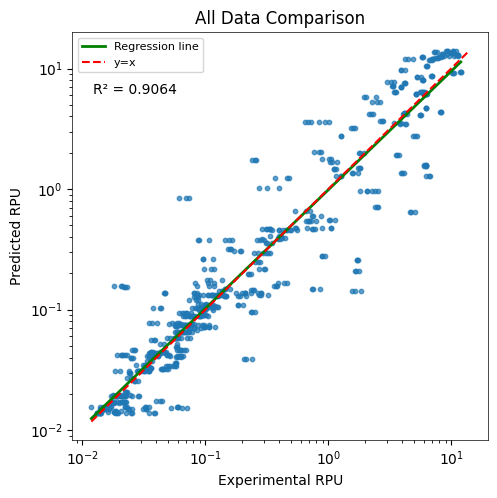

原始空间 R²: 0.6143
对数空间 R²: 0.9064


In [406]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import r2_score

# 三个文件路径
file_paths = [
    "E:\Desktop\mamm\\403_pre.csv",
    "E:\Desktop\mamm\\404_pre.csv",
    "E:\Desktop\mamm\\405_pre.csv",
    "E:\Desktop\mamm\\406_pre.csv",
    "E:\Desktop\mamm\\407_pre.csv",
    "E:\Desktop\mamm\\408_pre.csv",
    "E:\Desktop\mamm\\409_pre.csv",
    "E:\Desktop\mamm\\410_pre.csv",
    "E:\Desktop\mamm\\412_pre.csv",
    "E:\Desktop\mamm\\413_pre.csv",
    "E:\Desktop\mamm\\414_pre.csv",
    "E:\Desktop\mamm\\415_pre.csv",
    "E:\Desktop\mamm\\540_pre.csv",
    "E:\Desktop\mamm\\541_pre.csv",
    "E:\Desktop\mamm\\542_pre.csv",
]

# 合并数据
all_exp, all_pre = [], []

for path in file_paths:
    df = pd.read_csv(path)
    all_exp.extend(df['RPU'].values)
    all_pre.extend(df['P1_fit'].values)

# 转为 numpy 数组
exp = np.array(all_exp)
pre = np.array(all_pre)

# 去除 <=0 的值以避免 log 错误
valid = (exp > 0) & (pre > 0)
exp = exp[valid]
pre = pre[valid]

# 计算对数
exp_log = np.log10(exp)
pre_log = np.log10(pre)

# 在对数空间中进行回归拟合
slope, intercept, r_value, p_value, std_err = linregress(exp_log, pre_log)
r_squared_log = r_value**2

# 原始空间 R²
r2_raw = r2_score(exp, pre)

# 可视化（log-log 空间）
fig, ax = plt.subplots(figsize=(5.08, 5.08))
ax.scatter(exp, pre, s=10, alpha=0.7)

# 绘制回归线 - 在对数空间中计算，然后转换回原始空间显示
x_range_log = np.linspace(min(exp_log), max(exp_log), 100)
y_range_log = slope * x_range_log + intercept
x_range = 10**x_range_log
y_range = 10**y_range_log
ax.plot(x_range, y_range, color='green', linewidth=2, label='Regression line')

# 绘制y=x参考线
min_val = min(np.min(exp), np.min(pre))
max_val = max(np.max(exp), np.max(pre))
x_ref = np.logspace(np.log10(min_val), np.log10(max_val), 100)
ax.plot(x_ref, x_ref, 'r--', linewidth=1.5, label='y=x')

ax.set_xlabel("Experimental RPU", fontsize=10)
ax.set_ylabel("Predicted RPU", fontsize=10)
ax.set_title('All Data Comparison', fontsize=12)
ax.set_xscale("log")
ax.set_yscale("log")

# 添加图例
ax.legend(fontsize=8)

# 标注
ax.annotate(f"R² = {r_squared_log:.4f}", xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10)

# 美化边框
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.savefig("E:\\Desktop\mamm\\all_R².svg")
plt.show()

print(f"原始空间 R²: {r2_raw:.4f}")
print(f"对数空间 R²: {r_squared_log:.4f}")